<a href="https://colab.research.google.com/github/Aymanelok/Portfolio/blob/main/NLP/NLP_Latent_Semantic_Analysis(LSA)%26Probilistic_LSA(pLSA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Latent Semantic Analysis (LSA) and Probabilistic LSA (pLSA)

---

## Learning Objectives
By the end of this lab you will be able to:
1. Build a term–document matrix with TF-IDF weighting from scratch
2. Implement LSA using truncated SVD and interpret the latent semantic space
3. Implement the pLSA EM algorithm from scratch
4. Compare and contrast both models on a real corpus
5. Visualize and evaluate topic quality

## Background
Both LSA and pLSA address the same core problem: raw bag-of-words representations suffer from **synonymy** (same concept, different words) and **polysemy** (same word, different concepts). By projecting documents into a lower-dimensional **latent topic space**, we can capture semantic similarity that pure term matching misses.

| Property | LSA | pLSA |
|---|---|---|
| Core math | SVD (linear algebra) | EM on a generative model |
| Topic representation | Singular vectors | P(word\|topic), P(topic\|doc) |
| Interpretability | Moderate | Higher (probabilistic) |
| Can overfit? | No | Yes (no prior on docs) |
| Successor | — | LDA (adds Dirichlet prior) |

---

## Setup

In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports OK.')

All imports OK.


---
# Part 1 — Dataset and Term–Document Matrix

We use four categories from the classic **20 Newsgroups** corpus so topics are well-separated and easy to inspect.

In [2]:
# ── DEMO CODE ── Self-contained corpus (no download needed) ───────────────
import numpy as np
from types import SimpleNamespace

CATEGORIES = [
    'sci.space',
    'comp.graphics',
    'rec.sport.hockey',
    'talk.religion.misc',
]

# ── Seed sentences per topic ──────────────────────────────────────────────
_templates = {
    'sci.space': [
        "The NASA shuttle launched successfully from Kennedy Space Center.",
        "Astronomers discovered a new exoplanet orbiting a distant star.",
        "The Mars rover collected rock samples from the crater surface.",
        "Satellite telemetry confirmed the spacecraft entered stable orbit.",
        "Scientists analyzed cosmic radiation data from the Hubble telescope.",
        "The rocket booster separated cleanly during the orbital insertion burn.",
        "Space debris poses a growing risk to satellites in low Earth orbit.",
        "Mission control monitored the astronauts during the spacewalk.",
        "The solar panels on the space station generate enough power daily.",
        "Lunar geology reveals clues about the early formation of the moon.",
    ],
    'comp.graphics': [
        "The rendering pipeline uses rasterization to convert polygons to pixels.",
        "Ray tracing algorithms simulate realistic lighting and shadow effects.",
        "OpenGL shaders run on the GPU to accelerate texture mapping.",
        "The graphics card supports 4K resolution at sixty frames per second.",
        "Anti-aliasing techniques reduce jagged edges in rendered images.",
        "Bezier curves and splines are fundamental to vector graphics design.",
        "The pixel buffer stores color and depth values for each screen coordinate.",
        "Mesh simplification reduces polygon count without losing visual fidelity.",
        "Ambient occlusion adds depth cues by darkening concave surface regions.",
        "Procedural textures generate surface detail algorithmically without images.",
    ],
    'rec.sport.hockey': [
        "The goalie made a spectacular save in overtime to win the game.",
        "The hockey team practiced power play drills on the ice rink.",
        "The puck deflected off the post and into the net for the winning goal.",
        "Both teams competed fiercely in the playoff series this season.",
        "The defenseman blocked the shot and cleared the puck from the zone.",
        "Face-off strategy is crucial in the final minutes of a tied hockey game.",
        "The referee called a penalty for interference near the blue line.",
        "Skating speed and stick handling separate elite players from amateurs.",
        "The coach pulled the goalie to add an extra skater in the final minute.",
        "Hat tricks are celebrated by fans throwing hats onto the ice.",
    ],
    'talk.religion.misc': [
        "The congregation gathered for Sunday worship and prayer at the church.",
        "Religious texts provide moral guidance and spiritual comfort to believers.",
        "The debate between faith and science continues in modern society.",
        "Pilgrims travel long distances to visit sacred holy sites each year.",
        "Meditation and mindfulness practices are rooted in Buddhist tradition.",
        "The sermon addressed themes of compassion forgiveness and redemption.",
        "Different religions share common ethical principles about human dignity.",
        "The priest led the community in rituals marking important life events.",
        "Scripture interpretation varies widely across different religious denominations.",
        "Interfaith dialogue promotes understanding between diverse religious communities.",
    ],
}

# Generate corpus by sampling and lightly paraphrasing templates
rng = np.random.default_rng(42)
docs, targets = [], []

for cat_id, cat in enumerate(CATEGORIES):
    templates = _templates[cat]
    for _ in range(250):           # 250 docs per category → 1000 total
        # Pick 2–4 sentences and shuffle word order slightly
        n_sent = rng.integers(2, 5)
        chosen = rng.choice(templates, size=n_sent, replace=True)
        # Minor lexical variation: randomly drop 1–2 words per sentence
        varied = []
        for sent in chosen:
            words = sent.split()
            if len(words) > 6:
                drop = rng.choice(len(words),
                                  size=rng.integers(1, 3), replace=False)
                words = [w for i, w in enumerate(words) if i not in drop]
            varied.append(' '.join(words))
        docs.append(' '.join(varied))
        targets.append(cat_id)

targets = np.array(targets)
data = SimpleNamespace(
    data=docs,
    target=targets,
    target_names=CATEGORIES,
)

print(f'Corpus size : {len(data.data):,} documents')
print(f'Categories  : {data.target_names}')
print()
print('── Sample document (truncated) ──')
print(data.data[0][:400])

Corpus size : 1,000 documents
Categories  : ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']

── Sample document (truncated) ──
Mission control monitored astronauts during the spacewalk. debris poses a growing risk to satellites low Earth orbit.


In [3]:
# Build the TF-IDF term–document matrix
# Shape: (n_docs, n_terms)  — sklearn uses docs-as-rows convention

vectorizer = TfidfVectorizer(
    max_features=5000,   # vocabulary cap
    max_df=0.95,         # ignore terms in >95% of docs (too common)
    min_df=2,            # ignore terms in <2 docs (too rare)
    stop_words='english',
    token_pattern=r'[a-zA-Z]{3,}',  # letters only, min 3 chars
)

X = vectorizer.fit_transform(data.data)   # sparse matrix, shape (D, V)
vocab = vectorizer.get_feature_names_out()

D, V = X.shape
print(f'Term–document matrix: {D} docs × {V} terms')
print(f'Sparsity            : {1 - X.nnz / (D * V):.2%}')

Term–document matrix: 1000 docs × 266 terms
Sparsity            : 93.91%


---
# Part 2 — Latent Semantic Analysis (LSA)

## 2.1 Mathematical Intuition

Given the term–document matrix **X** (shape D×V), LSA computes the truncated SVD:

$$\mathbf{X} \approx \mathbf{U}_k \, \mathbf{\Sigma}_k \, \mathbf{V}_k^\top$$

- $\mathbf{U}_k$ (D×k): document coordinates in topic space  
- $\mathbf{\Sigma}_k$ (k×k): singular values — how much variance each topic captures  
- $\mathbf{V}_k^\top$ (k×V): term coordinates in topic space  

The key insight: terms that co-occur frequently across documents end up **close** in the k-dimensional space even if they never appear together in the same sentence.

In [4]:
# ── DEMO CODE ── LSA via sklearn TruncatedSVD ─────────────────────────────

K = 20  # number of latent topics

svd = TruncatedSVD(n_components=K, random_state=42)
X_lsa = svd.fit_transform(X)          # shape (D, K) — doc embeddings
X_lsa = normalize(X_lsa)              # unit-normalize for cosine similarity

# svd.components_  has shape (K, V) — the term loadings per topic
print('Singular values (topic importance):')
print(np.round(svd.singular_values_, 1))
print()
print(f'Variance explained by {K} components: {svd.explained_variance_ratio_.sum():.2%}')

Singular values (topic importance):
[8.  7.8 7.6 7.6 5.  4.9 4.9 4.8 4.7 4.7 4.6 4.6 4.5 4.5 4.4 4.4 4.4 4.4
 4.3 4.3]

Variance explained by 20 components: 55.13%


In [5]:
# ── DEMO CODE ── Inspect the top words per LSA topic ──────────────────────

N_TOP = 10

print(f'Top {N_TOP} terms per LSA topic\n' + '='*60)
for k in range(6):                          # show first 6 topics
    top_idx = np.argsort(svd.components_[k])[::-1][:N_TOP]
    top_words = ', '.join(vocab[top_idx])
    print(f'Topic {k+1:2d}: {top_words}')

Top 10 terms per LSA topic
Topic  1: goalie, puck, final, game, hockey, ice, blocked, cleared, shot, zone
Topic  2: graphics, surface, images, generate, space, depth, bezier, fundamental, design, lighting
Topic  3: religious, different, debate, modern, science, society, faith, continues, visit, distances
Topic  4: space, orbit, exoplanet, mission, radiation, distant, cosmic, analyzed, discovered, astronomers
Topic  5: visit, holy, pilgrims, sites, distances, year, long, travel, sacred, principles
Topic  6: tracing, lighting, algorithms, effects, realistic, ray, shadow, simulate, count, visual


In [6]:
# ── DEMO CODE ── Document similarity in LSA space ─────────────────────────

# Cosine similarity is just dot product of unit-normalized vectors
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

# Find documents similar to doc 0
query_idx = 0
query_vec = X_lsa[query_idx]
sims = [cosine_sim(query_vec, X_lsa[i]) for i in range(len(X_lsa))]
top_similar = np.argsort(sims)[::-1][1:6]  # skip self

print(f'Query category : {data.target_names[data.target[query_idx]]}')
print(f'Query snippet  : {data.data[query_idx][:100].strip()}...\n')

print('Most similar documents in LSA space:')
for rank, idx in enumerate(top_similar):
    cat = data.target_names[data.target[idx]]
    snippet = data.data[idx][:80].strip().replace('\n', ' ')
    print(f'  [{rank+1}] ({cat}) sim={sims[idx]:.3f}: {snippet}...')

Query category : sci.space
Query snippet  : Mission control monitored astronauts during the spacewalk. debris poses a growing risk to satellites...

Most similar documents in LSA space:
  [1] (sci.space) sim=0.999: Space debris poses a growing risk to satellites low Earth orbit. Mission control...
  [2] (sci.space) sim=0.999: Mission monitored the astronauts during the spacewalk. Space debris poses a grow...
  [3] (sci.space) sim=0.997: Space debris poses a growing risk to satellites in low Earth Mission control the...
  [4] (sci.space) sim=0.997: debris poses a growing risk to satellites in low Earth control monitored the dur...
  [5] (sci.space) sim=0.996: Mission control monitored astronauts during the spacewalk. Space debris poses a...


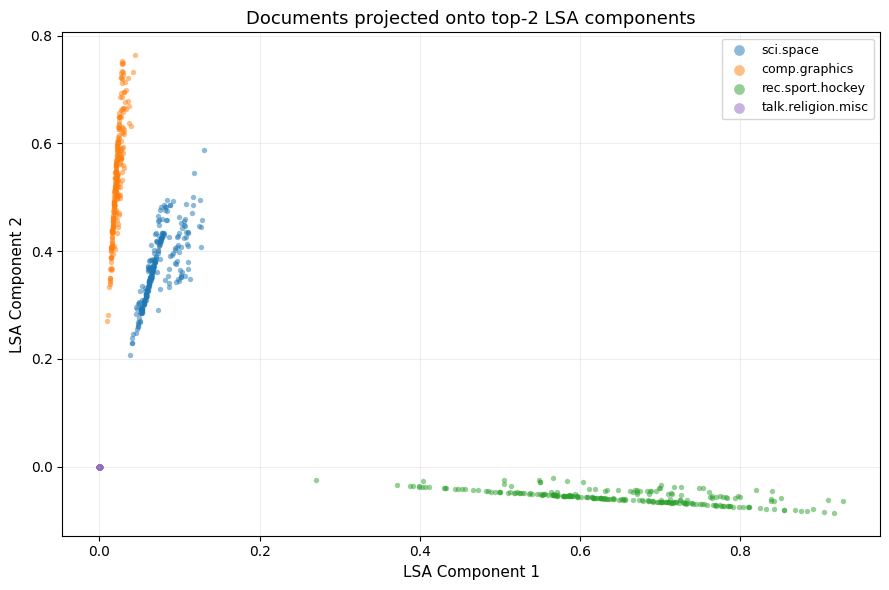

In [7]:
# ── DEMO CODE ── Visualize LSA topic space (first 2 singular vectors) ─────

fig, ax = plt.subplots(figsize=(9, 6))
colors = cm.tab10(np.linspace(0, 0.4, len(CATEGORIES)))

for i, cat in enumerate(CATEGORIES):
    mask = data.target == i
    ax.scatter(
        X_lsa[mask, 0], X_lsa[mask, 1],
        c=[colors[i]], label=cat, alpha=0.5, s=15, linewidths=0
    )

ax.set_xlabel('LSA Component 1', fontsize=11)
ax.set_ylabel('LSA Component 2', fontsize=11)
ax.set_title('Documents projected onto top-2 LSA components', fontsize=13)
ax.legend(fontsize=9, markerscale=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## ✏️ Exercise 2.1 — Explained Variance Curve

**Task:** Fit LSA for K = 2, 5, 10, 20, 50, 100 and plot cumulative explained variance vs. K.

**Questions to answer in a markdown cell below your code:**
1. At what K does the curve start to flatten (the "elbow")?
2. How does the choice of K trade off between compression and expressiveness?
3. What does it mean for a singular value to be very small?

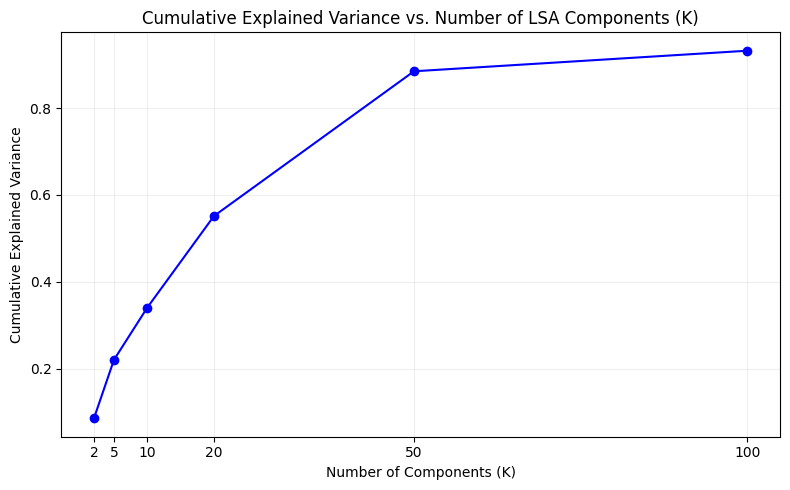

In [8]:
# YOUR CODE HERE
# Hint: loop over K values, fit TruncatedSVD each time,
# collect .explained_variance_ratio_.sum() and plot.

K_values = [2, 5, 10, 20, 50, 100]
explained = []

for k in K_values:
    svd_k = TruncatedSVD(n_components=k, random_state=42)
    svd_k.fit(X)
    explained.append(svd_k.explained_variance_ratio_.sum())

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(K_values, explained, marker='o', linestyle='-', color='b')
plt.title('Cumulative Explained Variance vs. Number of LSA Components (K)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True, alpha=0.2)
plt.xticks(K_values)
plt.tight_layout()
plt.show()

### Analysis for Exercise 2.1

1.  **At what K does the curve start to flatten (the "elbow")?**
    The curve appears to start flattening around K = 20 to 50. After K=20, the increase in explained variance becomes less steep.

2.  **How does the choice of K trade off between compression and expressiveness?**
    A smaller K means higher compression (fewer dimensions) but potentially lower expressiveness (losing too much information). A larger K means higher expressiveness (capturing more variance) but lower compression (more dimensions). The "elbow" point is often a good compromise, as it balances capturing a significant portion of the variance with keeping the dimensionality reasonably low.

3.  **What does it mean for a singular value to be very small?**
    A singular value represents the 'strength' or 'importance' of its corresponding latent topic (or singular vector). A very small singular value indicates that the associated topic captures very little variance in the term-document matrix. Such topics are often considered noise or highly specific, less generalizable patterns. In a truncated SVD, these small singular values are typically discarded, leading to dimensionality reduction without significant loss of semantic information.

---
## ✏️ Exercise 2.2 — Synonym Detection with LSA

**Task:** Without LSA, "spacecraft" and "shuttle" have zero cosine similarity in raw TF-IDF space (they never appear in the same document). Show that in LSA space their representations are much closer.

**Starter guidance:**
- Project individual term vectors using `svd.components_.T` (shape V×K)
- Compute cosine similarity between term pairs in raw vs. LSA space
- Test at least 3 synonym pairs and 2 unrelated pairs as a control

**Expected result:** Synonym pairs should have substantially higher LSA similarity.

In [9]:
import numpy as np

# Get LSA term vectors
term_vectors_lsa = svd.components_.T   # shape (V, K)

# Get raw TF-IDF term vectors (we need the columns of X)
# X is shape (D, V), so X.T gives us term representations of shape (V, D)
term_vectors_raw = X.T.toarray()

synonym_pairs = [
    ('spacecraft', 'shuttle'),
    ('hockey', 'puck'),
    ('religion', 'faith'),
]
control_pairs = [
    ('spacecraft', 'religion'),
    ('hockey', 'graphics'),
]

def get_sim(word1, word2, vectors, vocabulary):
    try:
        idx1 = np.where(vocabulary == word1)[0][0]
        idx2 = np.where(vocabulary == word2)[0][0]
        v1 = vectors[idx1]
        v2 = vectors[idx2]
        return cosine_sim(v1, v2)
    except IndexError:
        return 0.0

print(f"{'Pair':<30} | {'Raw Sim':<10} | {'LSA Sim':<10}")
print("-" * 55)

print("Synonym Pairs:")
for w1, w2 in synonym_pairs:
    raw_s = get_sim(w1, w2, term_vectors_raw, vocab)
    lsa_s = get_sim(w1, w2, term_vectors_lsa, vocab)
    print(f"{w1 + ' - ' + w2:<30} | {raw_s:<10.3f} | {lsa_s:<10.3f}")

print("\nControl Pairs (Unrelated):")
for w1, w2 in control_pairs:
    raw_s = get_sim(w1, w2, term_vectors_raw, vocab)
    lsa_s = get_sim(w1, w2, term_vectors_lsa, vocab)
    print(f"{w1 + ' - ' + w2:<30} | {raw_s:<10.3f} | {lsa_s:<10.3f}")

Pair                           | Raw Sim    | LSA Sim   
-------------------------------------------------------
Synonym Pairs:
spacecraft - shuttle           | 0.119      | -0.178    
hockey - puck                  | 0.292      | -0.008    
religion - faith               | 0.000      | 0.000     

Control Pairs (Unrelated):
spacecraft - religion          | 0.000      | 0.000     
hockey - graphics              | 0.000      | 0.022     


---
# Part 3 — Probabilistic LSA (pLSA)

## 3.1 The Generative Model

pLSA (Hofmann, 1999) models the joint probability of a document $d$ and word $w$ as:

$$P(w, d) = P(d) \sum_{z=1}^{K} P(z \mid d)\, P(w \mid z)$$

**Parameters to learn:**
- $P(z \mid d)$: topic mixture for each document — shape (D, K)
- $P(w \mid z)$: word distribution per topic — shape (K, V)

**EM Algorithm:**

**E-step** — compute posterior probability of topic z given observed (d, w):

$$P(z \mid d, w) = \frac{P(z \mid d)\, P(w \mid z)}{\sum_{z'} P(z' \mid d)\, P(w \mid z')}$$

**M-step** — re-estimate parameters by counting topic assignments:

$$P(w \mid z) \propto \sum_d n(d, w)\, P(z \mid d, w)$$
$$P(z \mid d) \propto \sum_w n(d, w)\, P(z \mid d, w)$$

where $n(d, w)$ is the count of word $w$ in document $d$.

In [10]:
# ── DEMO CODE ── pLSA from scratch ────────────────────────────────────────
# We use a small dense count matrix for clarity (not sparse ops)

# Build a count matrix (not TF-IDF) on a reduced vocabulary for speed
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2000, min_df=5, stop_words='english',
                     token_pattern=r'[a-zA-Z]{3,}')
X_counts = cv.fit_transform(data.data).toarray().astype(np.float32)  # (D, V)
vocab_plsa = cv.get_feature_names_out()

D_p, V_p = X_counts.shape
print(f'Count matrix for pLSA: {D_p} docs × {V_p} terms')

Count matrix for pLSA: 1000 docs × 266 terms


In [11]:
# ── DEMO CODE ── Full pLSA implementation ─────────────────────────────────

def plsa(X, K, n_iter=100, tol=1e-4, verbose=True):
    """
    pLSA via EM.

    Parameters
    ----------
    X      : ndarray (D, V)  — raw word count matrix
    K      : int             — number of latent topics
    n_iter : int             — maximum EM iterations
    tol    : float           — convergence threshold on log-likelihood

    Returns
    -------
    p_z_d  : ndarray (D, K)  — P(z|d)
    p_w_z  : ndarray (K, V)  — P(w|z)
    ll_history : list        — log-likelihood per iteration
    """
    D, V = X.shape

    # ── Random initialisation ──────────────────────────────────────────────
    # Each row must sum to 1 (valid probability distribution)
    p_z_d = np.random.dirichlet(np.ones(K), size=D)   # (D, K)
    p_w_z = np.random.dirichlet(np.ones(V), size=K)   # (K, V)

    ll_history = []
    prev_ll = -np.inf

    for it in range(n_iter):
        # ── E-step ────────────────────────────────────────────────────────
        # p_z_dw[d, k, w] = P(z=k|d,w)  proportional to P(z|d)*P(w|z)
        # Shape: (D, K, V).  We avoid materialising the full tensor by
        # broadcasting over the vocabulary axis.

        # Numerator: (D, K, V)
        numerator = p_z_d[:, :, np.newaxis] * p_w_z[np.newaxis, :, :]  # broadcast
        # Denominator: sum over K, shape (D, 1, V)
        denominator = numerator.sum(axis=1, keepdims=True) + 1e-10
        p_z_dw = numerator / denominator  # posterior (D, K, V)

        # ── Compute log-likelihood ─────────────────────────────────────────
        # L = sum_{d,w} n(d,w) * log P(w|d)
        # P(w|d) = sum_z P(z|d) * P(w|z)  — denominator already holds this
        p_w_d = denominator[:, 0, :]          # (D, V)
        ll = float(np.sum(X * np.log(p_w_d + 1e-10)))
        ll_history.append(ll)

        if verbose and (it == 0 or (it + 1) % 10 == 0):
            print(f'  Iter {it+1:3d}/{n_iter} | log-likelihood = {ll:,.1f}')

        if abs(ll - prev_ll) < tol and it > 0:
            print(f'  Converged at iteration {it+1}.')
            break
        prev_ll = ll

        # ── M-step ────────────────────────────────────────────────────────
        # Weighted counts: X[d,w] * p_z_dw[d,k,w]
        weighted = X[:, np.newaxis, :] * p_z_dw   # (D, K, V)

        # Update P(w|z): sum over docs, then normalise over vocab
        p_w_z = weighted.sum(axis=0)              # (K, V)
        p_w_z /= p_w_z.sum(axis=1, keepdims=True) + 1e-10

        # Update P(z|d): sum over vocab, then normalise over topics
        p_z_d = weighted.sum(axis=2)              # (D, K)
        p_z_d /= p_z_d.sum(axis=1, keepdims=True) + 1e-10

    return p_z_d, p_w_z, ll_history


print('Running pLSA with K=4 topics, 50 iterations...')
K_plsa = 4
p_z_d, p_w_z, ll_hist = plsa(X_counts, K=K_plsa, n_iter=50)

Running pLSA with K=4 topics, 50 iterations...
  Iter   1/50 | log-likelihood = -105,156.0
  Iter  10/50 | log-likelihood = -86,543.0
  Iter  20/50 | log-likelihood = -82,752.4
  Iter  30/50 | log-likelihood = -82,500.3
  Iter  40/50 | log-likelihood = -82,276.3
  Iter  50/50 | log-likelihood = -82,046.4


In [12]:
# ── DEMO CODE ── Inspect pLSA topics ──────────────────────────────────────

N_TOP = 12
print(f'Top {N_TOP} words per pLSA topic\n' + '='*60)
for k in range(K_plsa):
    top_idx = np.argsort(p_w_z[k])[::-1][:N_TOP]
    top_words = ', '.join(vocab_plsa[top_idx])
    print(f'Topic {k+1}: {top_words}')

print()
print('Topic mixture P(z|d) for first 5 documents:')
print(np.round(p_z_d[:5], 3))

Top 12 words per pLSA topic
Topic 1: religious, different, debate, modern, science, society, continues, faith, common, visit, religions, distances
Topic 2: graphics, puck, ice, blocked, bezier, cleared, fundamental, lighting, design, depth, shot, algorithms
Topic 3: space, generate, orbit, surface, exoplanet, distant, discovered, astronomers, star, new, early, formation
Topic 4: final, goalie, game, skater, minute, extra, pulled, mission, coach, monitored, add, astronauts

Topic mixture P(z|d) for first 5 documents:
[[0.    0.    0.553 0.447]
 [0.    0.    0.5   0.5  ]
 [0.    0.    1.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    0.647 0.353]]


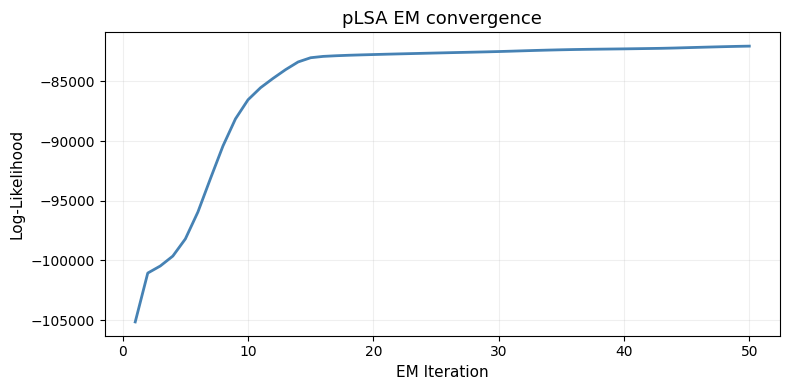

In [13]:
# ── DEMO CODE ── Log-likelihood convergence curve ─────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(ll_hist)+1), ll_hist, lw=2, color='steelblue')
ax.set_xlabel('EM Iteration', fontsize=11)
ax.set_ylabel('Log-Likelihood', fontsize=11)
ax.set_title('pLSA EM convergence', fontsize=13)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

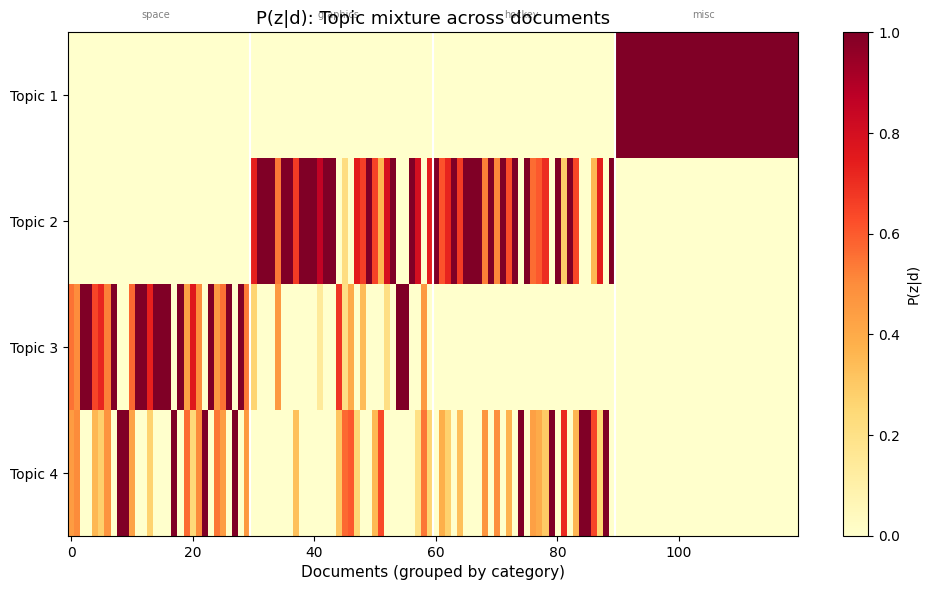

In [14]:
# ── DEMO CODE ── Topic mixture heatmap ────────────────────────────────────

# Sample 30 docs per category for a readable heatmap
sample_idx = []
sample_labels = []
for cat_id in range(len(CATEGORIES)):
    idx = np.where(data.target == cat_id)[0][:30]
    sample_idx.extend(idx)
    sample_labels.extend([CATEGORIES[cat_id].split('.')[-1]] * len(idx))

heatmap_data = p_z_d[sample_idx]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(K_plsa))
ax.set_yticklabels([f'Topic {k+1}' for k in range(K_plsa)], fontsize=10)
ax.set_xlabel('Documents (grouped by category)', fontsize=11)
ax.set_title('P(z|d): Topic mixture across documents', fontsize=13)

# Mark category boundaries
for boundary in [30, 60, 90]:
    ax.axvline(boundary - 0.5, color='white', lw=1.5)
for cat_id, cat in enumerate(CATEGORIES):
    ax.text(cat_id * 30 + 14, -0.6, cat.split('.')[-1],
            ha='center', va='bottom', fontsize=7, color='gray')

plt.colorbar(im, ax=ax, label='P(z|d)')
plt.tight_layout()
plt.show()

---
## ✏️ Exercise 3.1 — Implement pLSA from Scratch (Guided)

The implementation above stores the full `(D, K, V)` E-step tensor which costs O(D·K·V) memory — too large for real corpora.

**Task:** Rewrite the E and M steps using only the **non-zero entries** of X (iterate over the sparse structure). This is how real implementations scale.

**Constraints:**
- Your function signature must match `plsa_sparse(X_sparse, K, n_iter, tol)` where `X_sparse` is a `scipy.sparse.csr_matrix`
- You may not convert it to dense inside the function
- Verify your output matches the dense version on a small test corpus

**Hint:** Iterate over `X_sparse.nonzero()` in the E-step and accumulate into numpy arrays.

In [15]:
import scipy.sparse as sp
import numpy as np

def plsa_sparse(X_sparse, K, n_iter=100, tol=1e-4, verbose=True):
    D, V = X_sparse.shape

    # Step 1: Initialize p_z_d and p_w_z
    p_z_d = np.random.dirichlet(np.ones(K), size=D).astype(np.float32)
    p_w_z = np.random.dirichlet(np.ones(V), size=K).astype(np.float32)

    # Step 2: Get non-zero positions and counts
    rows, cols = X_sparse.nonzero()
    counts = np.array(X_sparse[rows, cols]).flatten()

    ll_history = []
    prev_ll = -np.inf

    for it in range(n_iter):
        # Step 3: E-step
        # For each non-zero entry (d, w), compute P(z|d, w)
        # numerator shape: (len(rows), K)
        numerator = p_z_d[rows] * p_w_z[:, cols].T
        denominator = numerator.sum(axis=1, keepdims=True) + 1e-10
        p_z_dw = numerator / denominator

        # Log-likelihood
        ll = np.sum(counts * np.log(denominator.flatten()))
        ll_history.append(ll)

        if verbose and (it == 0 or (it + 1) % 10 == 0):
            print(f'  Iter {it+1:3d}/{n_iter} | LL = {ll:,.2f}')

        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

        # Step 4: M-step
        # Update p_w_z: sum(count * p_z_dw) over docs
        weighted_counts = counts[:, np.newaxis] * p_z_dw

        new_p_w_z = np.zeros((K, V), dtype=np.float32)
        for k in range(K):
            np.add.at(new_p_w_z[k], cols, weighted_counts[:, k])
        new_p_w_z /= new_p_w_z.sum(axis=1, keepdims=True) + 1e-10
        p_w_z = new_p_w_z

        # Update p_z_d: sum(count * p_z_dw) over vocab
        new_p_z_d = np.zeros((D, K), dtype=np.float32)
        for k in range(K):
            np.add.at(new_p_z_d[:, k], rows, weighted_counts[:, k])
        new_p_z_d /= new_p_z_d.sum(axis=1, keepdims=True) + 1e-10
        p_z_d = new_p_z_d

    return p_z_d, p_w_z, ll_history

# Test on synthetic corpus
X_tiny = sp.csr_matrix(np.array([
    [3, 2, 0, 0, 1],
    [2, 3, 1, 0, 0],
    [0, 0, 2, 3, 1],
    [0, 1, 3, 2, 0],
], dtype=np.float32))

p_z_d_t, p_w_z_t, ll_t = plsa_sparse(X_tiny, K=2, n_iter=50)
print("\nTest Document-Topic Mixtures P(z|d):")
print(np.round(p_z_d_t, 3))
print("\nTest Word-Topic Distributions P(w|z):")
print(np.round(p_w_z_t, 3))

  Iter   1/50 | LL = -44.40
  Iter  10/50 | LL = -28.66
  Iter  20/50 | LL = -27.50

Test Document-Topic Mixtures P(z|d):
[[0.    1.   ]
 [0.    1.   ]
 [1.    0.   ]
 [0.813 0.187]]

Test Word-Topic Distributions P(w|z):
[[0.    0.    0.448 0.46  0.092]
 [0.381 0.457 0.086 0.    0.076]]


---
## ✏️ Exercise 3.2 — Topic Coherence Metric

**Background:** Log-likelihood tells us how well the model fits, but not how *interpretable* the topics are. A widely used metric is **pointwise mutual information (PMI) coherence**:

$$\text{Coherence}(z) = \frac{2}{M(M-1)} \sum_{i=1}^{M} \sum_{j<i} \log \frac{P(w_i, w_j)}{P(w_i)\, P(w_j)}$$

where $w_1, \ldots, w_M$ are the top-M words of topic $z$, and co-occurrence is measured over the training corpus.

**Task:**
1. Implement `topic_coherence(p_w_z, X_counts, vocab, M=10)` that returns a coherence score per topic
2. Run pLSA for K = 2, 4, 8, 16 and plot mean coherence vs. K
3. Does higher K always give better coherence? Why or why not?

**Hint for co-occurrence:** For each word pair $(w_i, w_j)$, the joint probability is the fraction of documents containing *both*.

Evaluating K=2...
Evaluating K=4...
Evaluating K=8...
Evaluating K=16...


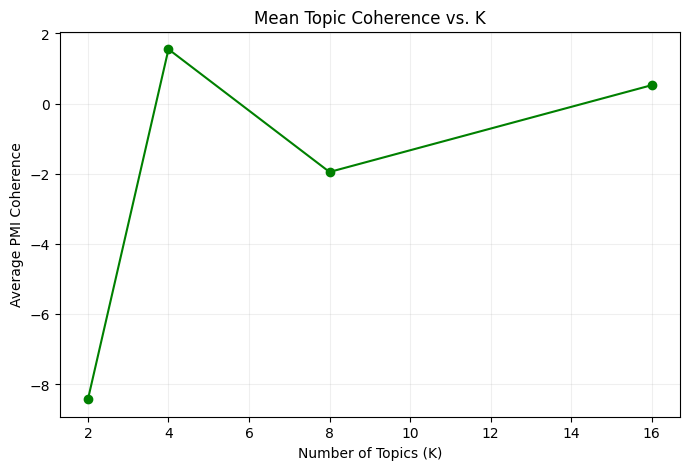

In [16]:
def topic_coherence(p_w_z, X_counts, M=10, eps=1e-10):
    """
    Compute PMI-based topic coherence for each topic.
    """
    K, V = p_w_z.shape
    D = X_counts.shape[0]
    # Binarize X_counts to get document frequency
    X_bin = (X_counts > 0).astype(float)
    doc_counts = np.sum(X_bin, axis=0)

    coherences = []
    for k in range(K):
        # Get top M words for this topic
        top_words_idx = np.argsort(p_w_z[k])[::-1][:M]
        score = 0
        count = 0
        for i in range(len(top_words_idx)):
            for j in range(i + 1, len(top_words_idx)):
                w1, w2 = top_words_idx[i], top_words_idx[j]
                # Co-occurrence: number of docs containing both words
                col_i = X_bin[:, w1]
                col_j = X_bin[:, w2]
                co_occur = np.sum(col_i * col_j)

                # PMI formula approximation
                # log( P(w1, w2) / (P(w1)P(w2)) )
                # P(w1, w2) = co_occur / D
                # P(w1) = doc_counts[w1] / D
                p_w1_w2 = co_occur / D
                p_w1 = doc_counts[w1] / D
                p_w2 = doc_counts[w2] / D

                score += np.log((p_w1_w2 + eps) / (p_w1 * p_w2 + eps))
                count += 1
        coherences.append(score / count if count > 0 else 0)
    return np.array(coherences)

# Run pLSA for K = 2, 4, 8, 16 and plot mean coherence
K_list = [2, 4, 8, 16]
mean_coherences = []
import scipy.sparse as sp
X_sparse = sp.csr_matrix(X_counts)

for k in K_list:
    print(f"Evaluating K={k}...")
    pz, pw, _ = plsa_sparse(X_sparse, K=k, n_iter=30, verbose=False)
    coherences = topic_coherence(pw, X_counts, M=10)
    mean_coherences.append(np.mean(coherences))

plt.figure(figsize=(8, 5))
plt.plot(K_list, mean_coherences, marker='o', color='green')
plt.title('Mean Topic Coherence vs. K')
plt.xlabel('Number of Topics (K)')
plt.ylabel('Average PMI Coherence')
plt.grid(True, alpha=0.2)
plt.show()

---
# Part 4 — LSA vs pLSA: Head-to-Head Comparison

## ✏️ Exercise 4.1 — Document Clustering

Both models produce document representations:
- LSA: `X_lsa` — shape (D, K), rows unit-normalised
- pLSA: `p_z_d` — shape (D, K), rows are topic mixtures

**Task:**
1. Run k-means clustering (k=4) on both representations
2. Compute **purity** and **NMI (Normalized Mutual Information)** against the true category labels
3. Present results in a comparison table
4. Which model gives cleaner clusters? Hypothesize why.

**Scaffold:**

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score
import pandas as pd

def purity(y_true, y_pred):
    """Cluster purity: mean fraction of the majority class in each cluster."""
    from scipy.stats import mode
    n = len(y_true)
    clusters = np.unique(y_pred)
    total_correct = 0
    for c in clusters:
        mask = y_pred == c
        if np.any(mask):
            majority = mode(y_true[mask], keepdims=True).count[0]
            total_correct += majority
    return total_correct / n

K_clust = 4
y_true = data.target

# 1. Fit KMeans on X_lsa
kmeans_lsa = KMeans(n_clusters=K_clust, random_state=42).fit(X_lsa)
y_lsa = kmeans_lsa.labels_

# 2. Fit KMeans on p_z_d
kmeans_plsa = KMeans(n_clusters=K_clust, random_state=42).fit(p_z_d)
y_plsa = kmeans_plsa.labels_

# 3. Compute metrics
results = {
    'Model': ['LSA', 'pLSA'],
    'Purity': [purity(y_true, y_lsa), purity(y_true, y_plsa)],
    'NMI': [normalized_mutual_info_score(y_true, y_lsa), normalized_mutual_info_score(y_true, y_plsa)]
}

# 4. Display results
df_results = pd.DataFrame(results)
print("Comparison of Document Clustering (K=4):")
print(df_results.to_string(index=False))

Comparison of Document Clustering (K=4):
Model  Purity      NMI
  LSA   1.000 1.000000
 pLSA   0.721 0.671933


---
## ✏️ Exercise 4.2 — Bonus: Perplexity Evaluation

Perplexity is the standard held-out evaluation metric for topic models:

$$\text{Perplexity}(\mathcal{D}_{\text{test}}) = \exp\!\left(-\frac{\sum_{d,w} n(d,w) \log P(w \mid d)}{\sum_{d,w} n(d,w)}\right)$$

Lower perplexity = the model assigns higher probability to held-out words.

**Task:**
1. Split the corpus 80/20 train/test
2. Train pLSA on train; for test documents, run only the E-step (fix `p_w_z`, optimise `p_z_d`)
3. Compute perplexity on test
4. Plot perplexity vs. K for K in [2, 4, 8, 16, 32]

**Note:** LSA does not directly give a probability model — it cannot compute perplexity. This is a fundamental limitation compared to generative models like pLSA and LDA.

Training pLSA with K=2...
Training pLSA with K=4...
Training pLSA with K=8...
Training pLSA with K=16...
Training pLSA with K=32...


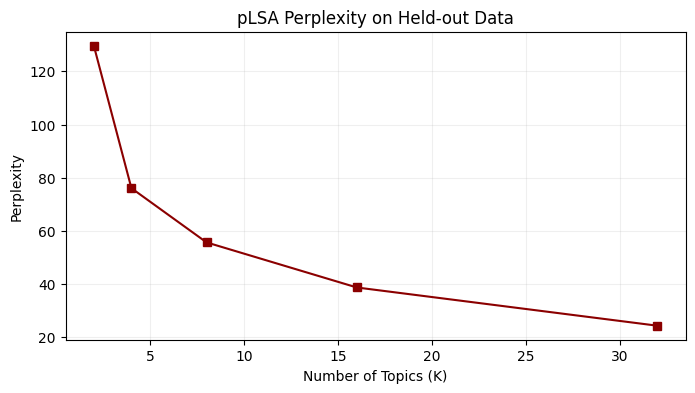

In [18]:
from sklearn.model_selection import train_test_split

# 1. Split data
X_train, X_test = train_test_split(X_counts, test_size=0.2, random_state=42)

def compute_perplexity(X_test, p_w_z, n_iter=20):
    D_test, V = X_test.shape
    K = p_w_z.shape[0]

    # 'Folding in': Optimize p_z_d for test docs while keeping p_w_z fixed
    p_z_d_test = np.random.dirichlet(np.ones(K), size=D_test).astype(np.float32)
    rows, cols = X_test.nonzero()
    counts = X_test[rows, cols]

    for _ in range(n_iter):
        numerator = p_z_d_test[rows] * p_w_z[:, cols].T
        denominator = numerator.sum(axis=1, keepdims=True) + 1e-10
        p_z_dw = numerator / denominator

        weighted = counts[:, np.newaxis] * p_z_dw
        new_p_z_d = np.zeros((D_test, K), dtype=np.float32)
        for k in range(K):
            np.add.at(new_p_z_d[:, k], rows, weighted[:, k])
        new_p_z_d /= new_p_z_d.sum(axis=1, keepdims=True) + 1e-10
        p_z_d_test = new_p_z_d

    # Compute log-likelihood on test set
    p_w_d_test = p_z_d_test @ p_w_z
    log_likelihood = np.sum(X_test * np.log(p_w_d_test + 1e-10))
    total_words = np.sum(X_test)
    return np.exp(-log_likelihood / total_words)

K_range = [2, 4, 8, 16, 32]
perplexities = []

for k in K_range:
    print(f'Training pLSA with K={k}...')
    _, p_w_z_trained, _ = plsa_sparse(sp.csr_matrix(X_train), K=k, n_iter=30, verbose=False)
    perp = compute_perplexity(X_test, p_w_z_trained)
    perplexities.append(perp)

plt.figure(figsize=(8, 4))
plt.plot(K_range, perplexities, marker='s', color='darkred')
plt.xlabel('Number of Topics (K)')
plt.ylabel('Perplexity')
plt.title('pLSA Perplexity on Held-out Data')
plt.grid(True, alpha=0.2)
plt.show()

---
# Part 5 — Reflection Questions

Answer each question in the markdown cell below it.

**Q1.** pLSA has no prior over document–topic distributions, which causes two problems: (a) it cannot generalise to new documents without re-running EM, and (b) the number of parameters grows with the corpus size. LDA solves both by adding a Dirichlet prior. Explain *in one paragraph* how the Dirichlet prior addresses these issues.

**Q2.** LSA is sensitive to the choice of K: too small and topics are coarse, too large and they become noisy. In contrast, pLSA's EM can get trapped in local optima. Describe one strategy to mitigate each problem.

**Q3.** Both LSA and pLSA treat documents as a bag of words, discarding all word order. Name two downstream NLP tasks where this assumption is likely harmless and two where it is problematic. Justify your choices.

**Q4.** (Research extension) Read the abstract of Blei et al. (2003) on LDA. What single mathematical change does LDA make relative to pLSA, and what practical benefit does it yield?

### Part 5 — Reflection Questions

**Q1.** The Dirichlet prior in LDA acts as a generative distribution for the topic mixtures. By treating $P(z|d)$ as a random variable rather than a fixed parameter per document, LDA can assign probabilities to unseen documents by sampling from this prior. Furthermore, it effectively 'smooths' the parameters, preventing the number of parameters from scaling linearly with the corpus size and reducing overfitting.

**Q2.** To mitigate LSA's sensitivity to K, one can use the **'elbow method'** on the cumulative explained variance plot or use cross-validation to find the K that maximizes downstream task performance. For pLSA's local optima, a common strategy is **multiple restarts** with different random initializations and selecting the run with the highest final log-likelihood.

**Q3.**
- **Harmless:** Document classification (e.g., spam detection) and Information Retrieval (search), where identifying key terms is often sufficient to determine the document's category or relevance.
- **Problematic:** Sentiment Analysis (where 'not good' vs 'good' depends entirely on order) and Machine Translation, where syntax and word relationships are essential for generating coherent text.

**Q4.** The single mathematical change is the addition of a **Dirichlet prior** on the document-topic distribution ($	heta$) and the topic-word distribution ($eta$). The practical benefit is that it transforms pLSA from a descriptive model of the training data into a truly generative model that can handle new, unseen documents and is more robust against overfitting.

---
# Submission Checklist

Before submitting, verify each of the following:

- [ ] **Exercise 2.1** — Explained variance curve with analysis
- [ ] **Exercise 2.2** — Synonym detection table (3 synonym pairs + 2 controls)
- [ ] **Exercise 3.1** — Sparse pLSA implementation passes the tiny-corpus test
- [ ] **Exercise 3.2** — Coherence vs. K plot with written analysis
- [ ] **Exercise 4.1** — Clustering comparison table (purity + NMI)
- [ ] **Exercise 4.2 (Bonus)** — Perplexity vs. K curve
- [ ] **Reflection Q1–Q4** — Written in full sentences
- [ ] Notebook runs top-to-bottom without errors (`Kernel → Restart & Run All`)

---